# Objectif du notebook 

Date de création : 23/01/2026

Analyse des RTFs pour des séquences d'émissions tractée. 

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sp 
from datetime import datetime, timedelta

# import gc

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color 
from propa.rtf.rtf_utils import D_hermitian_angle_fast

from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    FiberscopeManager,
    BandFilter,
)

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

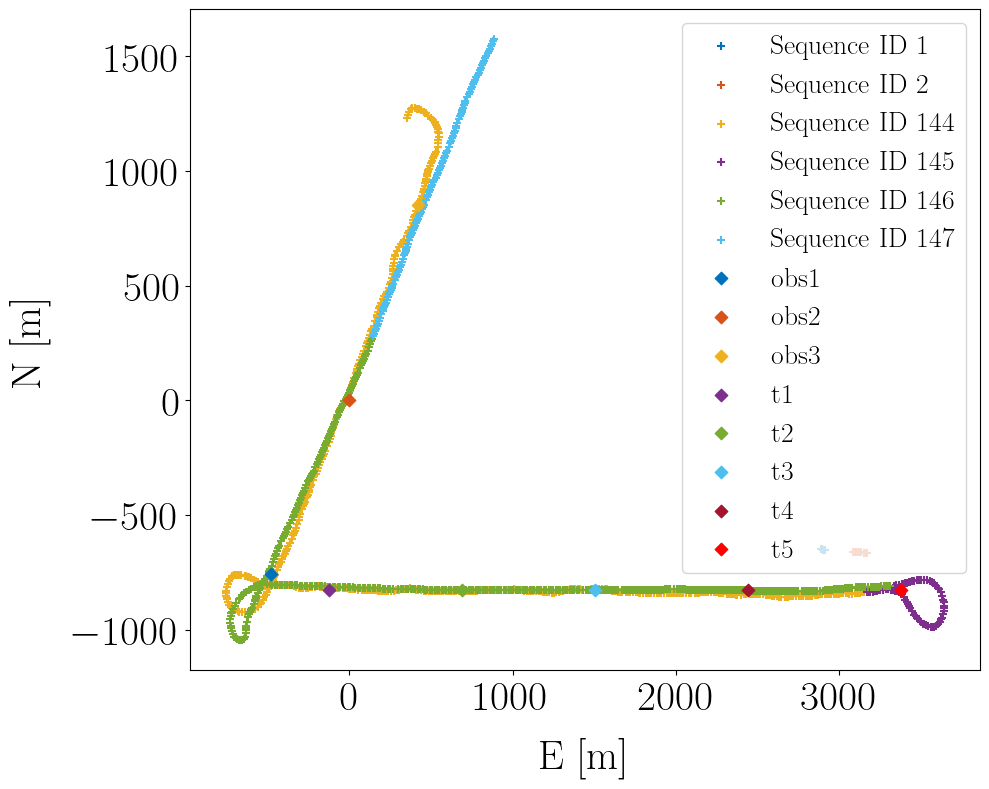

In [5]:
# Tracer des positions d'émission et des positions des OBS sur une carte
df_arr_plot = df_arr.loc[df_arr["src_pos_status"] == "trailed"]
sel_sequence_id_to_analyse = df_arr_plot["sequence_id"].unique()

seq_mean_fscore = []

# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score_obs1"].iloc[0]
        + df_sequence["f_score_obs2"].iloc[0]
        + df_sequence["f_score_obs3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)

    # Série de positions successives
    plt.scatter(
        df_sequence["emission_interp_e_gps"],
        df_sequence["emission_interp_n_gps"],
        marker="+",
        color=color(i),
        label=f"Sequence ID {seq_id}",
    )


plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=10,
        color=color(ik),
        s=40,
    )


plt.legend()

In [6]:
for i, seq_id in enumerate(sel_sequence_id_to_analyse): 
    print(f'ID {seq_id} -> {seq_mean_fscore[i]}')
# print(sel_sequence_id_to_analyse)
# print(seq_mean_fscore)

ID 1 -> 0.6288478705487782
ID 2 -> 0.5605573069468158
ID 144 -> 0.736994242229486
ID 145 -> 0.7040982306843718
ID 146 -> 0.7132676763051916
ID 147 -> 0.7692349999736839


# Étude de séquence tractée 

In [7]:
# seq_id = [144, 145, 146, 147]  # , 134, 135, 136, 143]
seq_id = [144]  # , 134, 135, 136, 143]

df_seq = df_arr.loc[df_arr["sequence_id"].isin(seq_id)]

# df_seq.head(25)

In [8]:
# Load wav data from netcdf
nc_fpath = os.path.join(data_folder, "channel_H_wav.nc")
ds_wav = xr.open_dataset(nc_fpath)

datetime_fmt = ds_wav.attrs["datetime_format"]
fs = ds_wav.attrs[f"fs_obs{1}"]
ts = 1/fs

In [9]:
# Select window size to compute RTF 
tau_ir_sim = 0.01       # Estimated impulse response duration (-30dB) on profile p1
tau_rtf_analysis = 10 * tau_ir_sim  # To ensure we include the entire response 

# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(
    tau_rtf_analysis * fs
)  
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.5
noverlap = int(nperseg * alpha_overlap)

print(f"nperseg = {nperseg}, noverlap = {noverlap}")

nperseg = 256, noverlap = 128


In [10]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True

fsm = FiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=3,
    process_pulse_one_by_one=process_pulse_one_by_one,
)

In [11]:
fsm.process_static_analysis(
    df_arrivals=df_seq,
    set_stft_props=True,
    rtf_estimator="cs-evd",
    verbose=False,
)

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

In [12]:
def get_dists(df_arr, seq_id_ref, seq_id, fmin=600, fmax=800):

    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

    fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_id_ref}_rtf.nc")
    xr_seq_ref = xr.open_dataset(fpath)

    df_seq_ref = df_arr.loc[df_arr["sequence_id"] == seq_id_ref]
    ref_pos_e = df_seq_ref["emission_interp_e_gps"].iloc[0]
    ref_pos_n = df_seq_ref["emission_interp_n_gps"].iloc[0]

    # Load rtf data
    fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_id}_rtf.nc")
    xr_seq_i = xr.open_dataset(fpath)
    df_seq_i = df_arr.loc[df_arr["sequence_id"] == seq_id]
    df_seq_i = df_seq_i.loc[df_seq_i["pulse_id"].isin(xr_seq_i.pulse_id.values)]

    # -----------------------------------------
    # 1) Evaluate spatial variations
    # -----------------------------------------
    # Emission positions in the sequence
    pos_e_pulse = df_seq_i["emission_interp_e_gps"]
    pos_n_pulse = df_seq_i["emission_interp_n_gps"]

    # Compute distance to all
    spatial_dist = np.sqrt((ref_pos_e - pos_e_pulse)**2 + (ref_pos_n - pos_n_pulse)**2)

    # -----------------------------------------
    # 2) Evaluate RTF variations
    # -----------------------------------------
    # Reference RTF <-> first pulse in sequence
    xr_seq_i_ref = xr_seq_ref.sel(pulse_id=0)
    rtf_ref = xr_seq_i_ref.rtf_amp_hat * np.exp(
        1j * xr_seq_i_ref.rtf_phase_hat
    )

    # Rtf for each pulse
    rtf_pulse = xr_seq_i.rtf_amp_hat * np.exp(1j * xr_seq_i.rtf_phase_hat)

    # Limit frequency band
    rtf_ref = rtf_ref.sel(f_rtf=slice(fmin, fmax))
    rtf_pulse = rtf_pulse.sel(f_rtf=slice(fmin, fmax))

    # Compute hermitian angle distance
    theta_dist = []
    for pulse_id in xr_seq_i.pulse_id.values:
        rtf_pulse_i = rtf_pulse.sel(pulse_id=pulse_id)
        theta = D_hermitian_angle_fast(
            rtf_ref=rtf_ref.values, rtf=rtf_pulse_i.values, **dist_kwargs
        )

        theta_dist.append(theta)

    # print(spatial_dist, theta_dist)
    spatial_dist = np.array(spatial_dist)
    theta_dist = np.array(theta_dist)

    return spatial_dist, theta_dist, xr_seq_i, df_seq_i

In [13]:
# Analyse rtf variations
fmin = 600
fmax = 900

seq_id_ref_obs1 = 151        # Sequence ref for obs 1
seq_id_ref_obs2 = 116        # Sequence ref for obs 2
seq_id_ref_obs3 = 127  # Sequence ref for obs 3
seq_refs = [seq_id_ref_obs1, seq_id_ref_obs2, seq_id_ref_obs3]

seq_id = 144 # Trailed sequence 

In [14]:
spatial_dist_obs = []
theta_dist_obs = []
for seq_id_ref in seq_refs:
    spatial_dist, theta_dist, xr_seq, df_seq = get_dists(
        df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_id, fmin=fmin, fmax=fmax
    )
    spatial_dist_obs.append(spatial_dist)
    theta_dist_obs.append(theta_dist)

pulse_id = xr_seq.pulse_id.values
pulse_dt = df_seq["emission_datetime"]

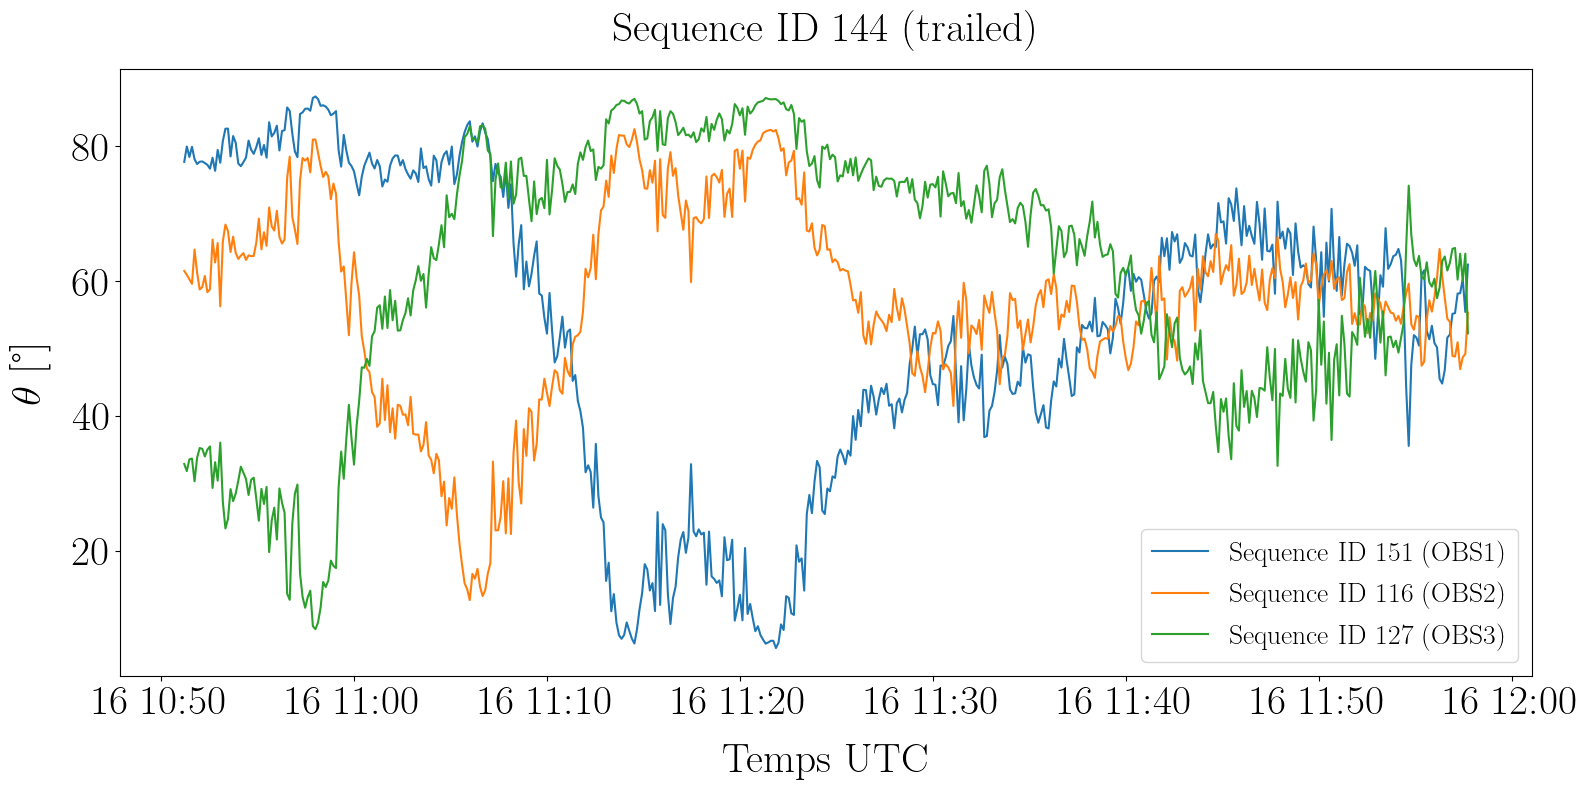

In [15]:
n_roll_avg = 1
plt.figure()
plt.title(f"Sequence ID {seq_id} (trailed)")
for i in range(len(spatial_dist_obs)):
    # plt.plot(pulse_id, theta_dist_obs[i], label=f"Sequence ID {seq_refs[i]} (OBS{i+1})")
    # plt.plot(pulse_dt, theta_dist_obs[i], label=f"Sequence ID {seq_refs[i]} (OBS{i+1})")


    theta_roll_i = np.convolve(
        theta_dist_obs[i], np.ones(n_roll_avg) / n_roll_avg, mode="same"
    )
    plt.plot(pulse_dt, theta_roll_i, label=f"Sequence ID {seq_refs[i]} (OBS{i+1})")

# plt.xlabel('Pulse ID')
plt.xlabel("Temps UTC")
plt.ylabel(r"$\theta$ [°]")

plt.legend()

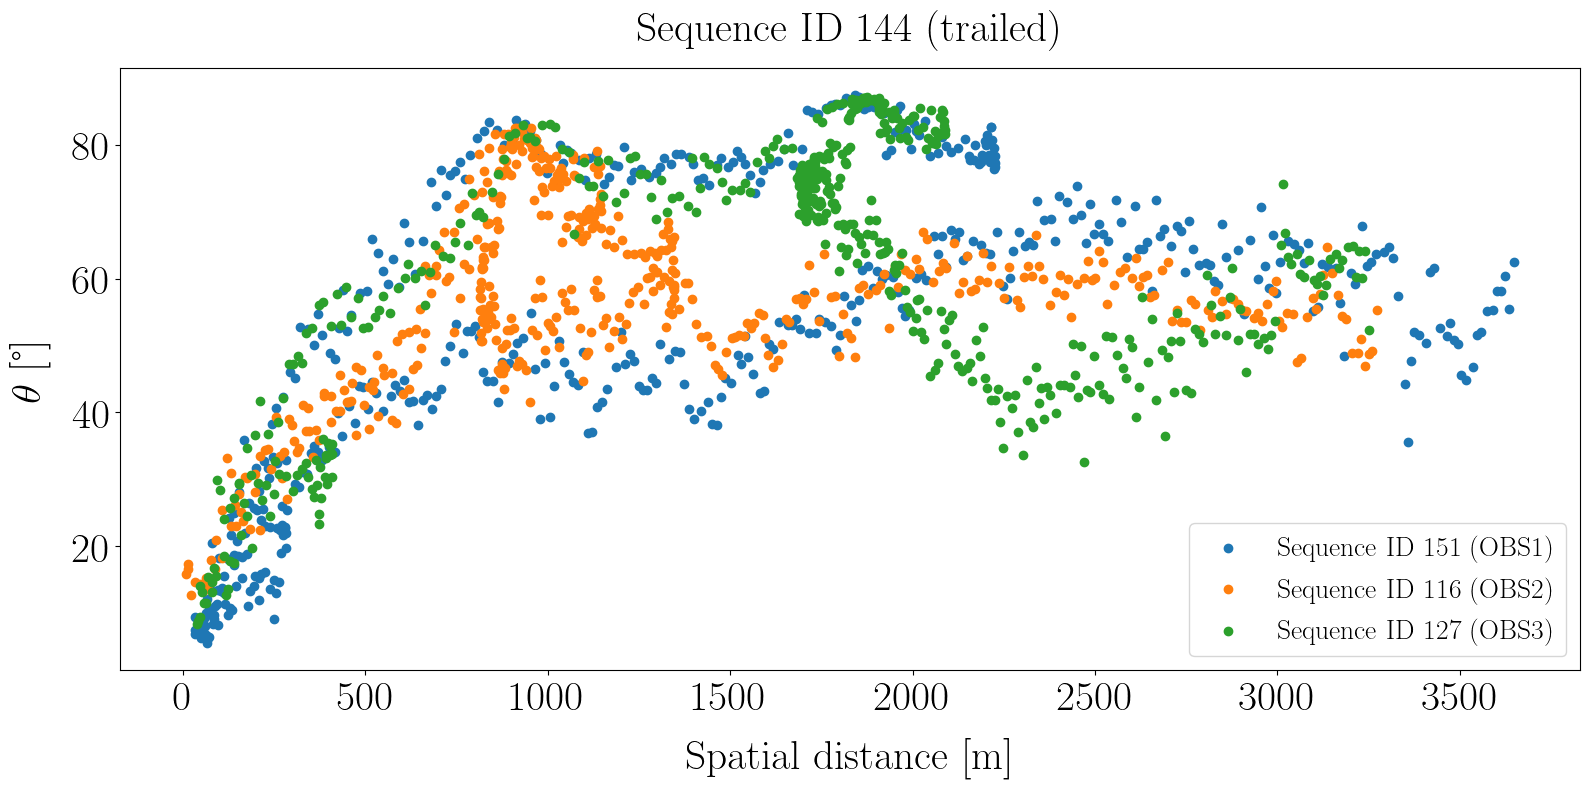

In [16]:
# # Sort by increasing distance
plt.figure()
plt.title(f"Sequence ID {seq_id} (trailed)")
for i in range(len(spatial_dist_obs)):
    dist_to_ref_argsort = np.argsort(spatial_dist_obs[i])
    sorted_spatial_dist = spatial_dist_obs[i][dist_to_ref_argsort]
    sorted_theta_dist = theta_dist_obs[i][dist_to_ref_argsort]

    plt.scatter(
        sorted_spatial_dist,
        sorted_theta_dist,
        label=f"Sequence ID {seq_refs[i]} (OBS{i+1})",
    )
plt.xlabel('Spatial distance [m]')
plt.ylabel(r"$\theta$ [°]")
plt.legend()

### Commentaires 

La distance theta varie linéairement avec la distance sur un domaine de distance restreint. 

Ceci est en accord avec l'existence d'une varieté acoustique : espace localement euclidien.  